#1. K-means Clustering

In [7]:
import numpy as np
import pandas as pd
from sklearn import datasets

In [8]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [9]:
from sklearn.cluster import KMeans
np.random.seed(5)
kmeans = KMeans(n_clusters=3)

#n_clusters 클러스터의 개수, 기본은 8
#n_jobs 병렬 처리 개수
#algorithm: full(EM방식), elkan(효율적 방식), auto(dense 자료에 elkan, sparse에 full)

#사용 함수
kmeans.fit(X)	#클러스터링
kmeans.fit_predict(X)	#클러스터 중심 계산 후 각 샘플의 클러스터를 예측, kmeans.labels_와 동일
kmeans.get_params()	#파라미터 출력
kmeans.predict(X[0:5,])	#입력된 X값들이 어떤 클러스터에 속할 지 계산
kmeans.predict([[0, 0, 0, 0], [1,1,4, 4]])

kmeans.transform(X)[1,]	#클러스터 중심으로부터의 거리로 변환된 값
X[1,]

#결과 활용
kmeans.labels_
kmeans.cluster_centers_
kmeans.inertia_		#각 클러스터내에서 센터와 각 자료 사이 거리 합의 제곱

78.8556658259773

In [10]:
#CSV를 읽은 후 k-means 클러스터링
csv_data = pd.read_csv("creditset.csv")
csv_data = csv_data.iloc[:, [0,1,2] ]	#2,3,4 열만 선택

kmeans = KMeans(n_clusters=3)
kmeans.fit(csv_data)	#클러스터링
kmeans.predict(csv_data)
kmeans.get_params()
kmeans.inertia_

#반복문으로 클러스터 개수별 K-means 비교하기
for numcl in [3,6,9]:
	kmeans2 = KMeans(n_clusters=numcl)
	kmeans2.fit(csv_data)
	print(kmeans2.inertia_)

59765445308.13854
26273848777.99834
18375368223.042892


In [11]:
#정규화:데이터 크기를 변환
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(csv_data)

for numcl in [3,6,9]:
	kmeans3 = KMeans(n_clusters=numcl)
	kmeans3.fit(scaled)
	print(kmeans3.inertia_)

209.18562701105978
124.50114177214505
89.82826682509953


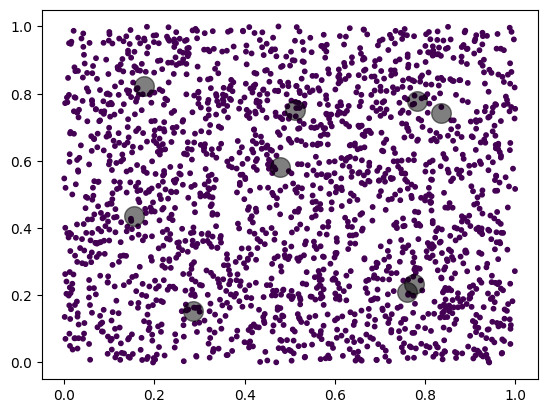

In [12]:
#matplotlib으로 시각화
import matplotlib.pyplot as plt
scaled_df = pd.DataFrame(scaled, columns=csv_data.columns)
plt.scatter(scaled_df['income'], scaled_df['age'], c=kmeans.predict(scaled_df), s=10 )
centers = kmeans3.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

#2.Agglomerative Clustering ( = Hierachical Clustering)

In [13]:
from time import time
import numpy as np
from sklearn import datasets

np.random.seed(5)

iris = datasets.load_iris()
X = iris.data
y = iris.target

In [14]:
from sklearn.cluster import AgglomerativeClustering
hclust = AgglomerativeClustering(linkage='ward', n_clusters=10)
#n_clusters 클러스터 개수, 초기값 2
#affinity 거리 측정 방식, 기본값 euclidean
#linkage ward, complete, average, 기본값은 ward (ward는 거리가 euclidean에서 가능)

hclust.fit(X)
hclust.fit_predict(X)
hclust.get_params()
hclust.labels_	#각 자료에 대한 클러스터 결과

array([9, 5, 5, 5, 9, 3, 5, 9, 5, 5, 3, 5, 5, 5, 3, 3, 3, 9, 3, 9, 3, 9,
       5, 9, 5, 5, 9, 9, 9, 5, 5, 3, 3, 3, 5, 5, 3, 9, 5, 9, 9, 5, 5, 9,
       9, 5, 9, 5, 3, 9, 8, 6, 8, 0, 8, 0, 6, 7, 8, 0, 7, 6, 0, 6, 0, 8,
       0, 0, 2, 0, 6, 6, 2, 6, 6, 8, 8, 4, 6, 0, 0, 0, 0, 2, 0, 6, 8, 2,
       0, 0, 0, 6, 0, 7, 0, 0, 0, 6, 7, 0, 4, 2, 1, 4, 4, 1, 0, 1, 4, 1,
       4, 4, 4, 2, 2, 4, 4, 1, 1, 2, 4, 2, 1, 2, 4, 1, 2, 6, 4, 1, 1, 1,
       4, 2, 2, 1, 4, 4, 6, 4, 4, 4, 2, 4, 4, 4, 2, 4, 4, 6])

In [15]:
for linkage in ('ward', 'average', 'complete'):
    clustering = AgglomerativeClustering(linkage=linkage, n_clusters=10)
    t0 = time()
    clustering.fit(X)
    print("%s : %.2fs" % (linkage, time() - t0))
    print(clustering.get_params())

ward : 0.00s
{'compute_distances': False, 'compute_full_tree': 'auto', 'connectivity': None, 'distance_threshold': None, 'linkage': 'ward', 'memory': None, 'metric': 'euclidean', 'n_clusters': 10}
average : 0.00s
{'compute_distances': False, 'compute_full_tree': 'auto', 'connectivity': None, 'distance_threshold': None, 'linkage': 'average', 'memory': None, 'metric': 'euclidean', 'n_clusters': 10}
complete : 0.00s
{'compute_distances': False, 'compute_full_tree': 'auto', 'connectivity': None, 'distance_threshold': None, 'linkage': 'complete', 'memory': None, 'metric': 'euclidean', 'n_clusters': 10}


In [16]:
#CSV를 읽은 후 Agglomerative 클러스터링
from pandas import read_csv
csv_data = read_csv("creditset.csv")	#또는 원하시는 경로를 지정해주세요. 예: c:/creditset.csv
csv_data = csv_data.iloc[:, [1,2,3]]	#2,3,4 열만 선택
print(csv_data.shape)

hclust = AgglomerativeClustering(linkage='ward', n_clusters=2)
hclust.fit(csv_data)
hclust.get_params()
hclust.labels_	#각 자료에 대한 클러스터 결과 출력

(2000, 3)


array([0, 0, 0, ..., 0, 1, 0], shape=(2000,))

In [17]:
from sklearn.cluster import AgglomerativeClustering
model2 = AgglomerativeClustering(n_clusters=10)
model2.fit(scaled)
model2.n_clusters
model2.labels_

array([0, 2, 0, ..., 6, 4, 0], shape=(2000,))

#3. MNIST 데이터 연습

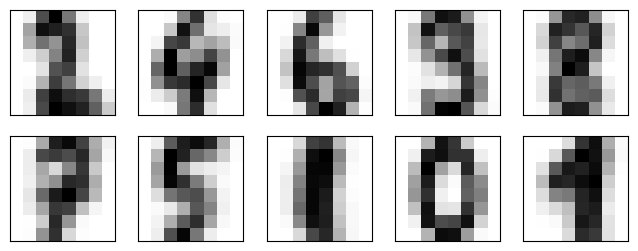

In [18]:
#MNIST digit 샘플 데이터
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
digits = load_digits()
digits.data.shape

#0~9의 숫자이므로 10개 군집
kmeans = KMeans(n_clusters=10)
clusters = kmeans.fit(digits.data)
kmeans.cluster_centers_.shape

# 시각화
fig, ax = plt.subplots(2, 5, figsize=(8, 3))	#10개의 그림을 2행5열로 표시
centers = kmeans.cluster_centers_.reshape(10, 8, 8)	#10개 숫자, 각 그림 픽셀 (8 by 8)로 shape 변경

#표시
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
plt.show()
